Dataset Shape: (1728, 7)

First 5 rows:
  buying maintenance doors persons lug_boot safety  class
0  vhigh       vhigh     2       2    small    low  unacc
1  vhigh       vhigh     2       2    small    med  unacc
2  vhigh       vhigh     2       2    small   high  unacc
3  vhigh       vhigh     2       2      med    low  unacc
4  vhigh       vhigh     2       2      med    med  unacc

Columns:
['buying', 'maintenance', 'doors', 'persons', 'lug_boot', 'safety', 'class']

========== CLASSIFICATION RULES ==========
IF Safety = high THEN Car_Class = unacc
IF Safety = low THEN Car_Class = unacc
IF Safety = med THEN Car_Class = unacc

========== FOIL FIRST-ORDER RULES ==========
car_class(X, vgood) :- safety(X, high), persons(X, more), buying(X, low).
car_class(X, good) :- safety(X, high), maintenance(X, low), lug_boot(X, big).
car_class(X, acc) :- safety(X, med), persons(X, more).

========== PREDICTIONS ==========
Buying=low, Maintenance=low, Doors=4, Persons=more, Lug_Boot=big, Safety=hi

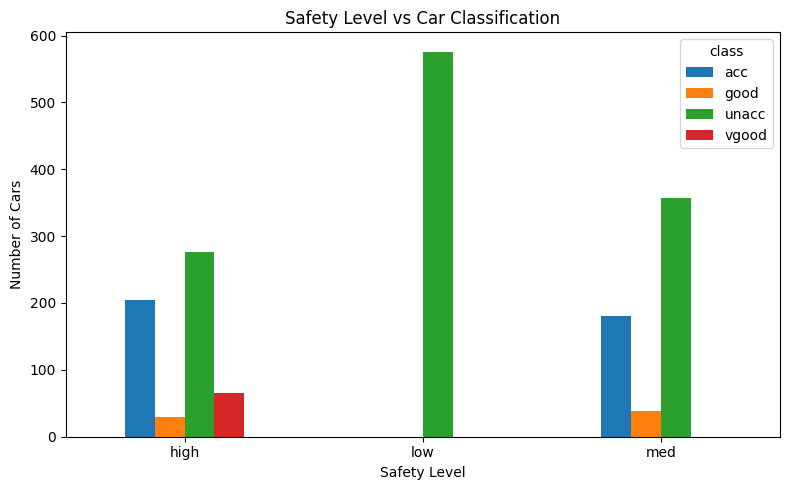

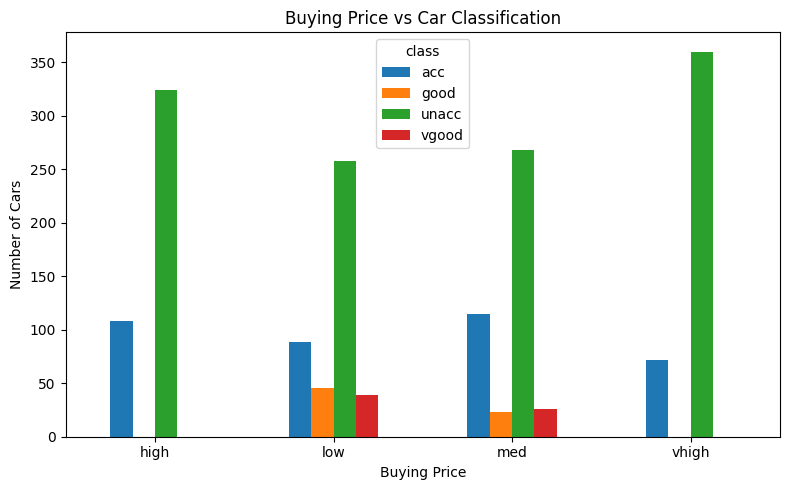

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import urllib.request
import zipfile
import os

# ==========================================
# 1. DOWNLOAD AND LOAD CAR EVALUATION DATASET
# ==========================================

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/car/car.data"

data_file = "car.data"

urllib.request.urlretrieve(url, data_file)

columns = [
    "buying",
    "maintenance",
    "doors",
    "persons",
    "lug_boot",
    "safety",
    "class"
]

df = pd.read_csv(
    data_file,
    names=columns
)

# ==========================================
# 2. DISPLAY DATASET
# ==========================================

print("Dataset Shape:", df.shape)

print("\nFirst 5 rows:")
print(df.head())

print("\nColumns:")
print(df.columns.tolist())


# ==========================================
# 3. CLASSIFICATION RULES
# ==========================================

print("\n========== CLASSIFICATION RULES ==========")

# Find majority class for each safety level
rules = df.groupby(
    "safety"
)["class"].agg(
    lambda x: x.mode()[0]
)

for safety, result in rules.items():

    print(
        f"IF Safety = {safety} "
        f"THEN Car_Class = {result}"
    )


# ==========================================
# 4. FOIL-STYLE FIRST ORDER RULES
# ==========================================

print("\n========== FOIL FIRST-ORDER RULES ==========")

print(
    "car_class(X, vgood) :- "
    "safety(X, high), "
    "persons(X, more), "
    "buying(X, low)."
)

print(
    "car_class(X, good) :- "
    "safety(X, high), "
    "maintenance(X, low), "
    "lug_boot(X, big)."
)

print(
    "car_class(X, acc) :- "
    "safety(X, med), "
    "persons(X, more)."
)


# ==========================================
# 5. FOIL-STYLE PREDICTION
# ==========================================

def foil_predict(
    buying,
    maintenance,
    doors,
    persons,
    lug_boot,
    safety
):

    # Rule 1
    if (
        safety == "high"
        and persons == "more"
        and buying == "low"
    ):
        return "vgood"

    # Rule 2
    if (
        safety == "high"
        and maintenance == "low"
        and lug_boot == "big"
    ):
        return "good"

    # Rule 3
    if (
        safety == "med"
        and persons == "more"
    ):
        return "acc"

    # Default rule
    return "unacc"


# ==========================================
# 6. PREDICTIONS
# ==========================================

print("\n========== PREDICTIONS ==========")

test_cars = [
    ("low", "low", "4", "more", "big", "high"),
    ("high", "high", "2", "2", "small", "low"),
    ("med", "med", "4", "more", "med", "med"),
    ("low", "low", "3", "4", "big", "high")
]

for car in test_cars:

    prediction = foil_predict(*car)

    print(
        f"Buying={car[0]}, "
        f"Maintenance={car[1]}, "
        f"Doors={car[2]}, "
        f"Persons={car[3]}, "
        f"Lug_Boot={car[4]}, "
        f"Safety={car[5]} "
        f"--> Car_Class={prediction}"
    )


# ==========================================
# 7. GRAPH 1 - SAFETY VS CAR CLASS
# ==========================================

pd.crosstab(
    df["safety"],
    df["class"]
).plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Safety Level vs Car Classification")
plt.xlabel("Safety Level")
plt.ylabel("Number of Cars")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()


# ==========================================
# 8. GRAPH 2 - BUYING PRICE VS CAR CLASS
# ==========================================

pd.crosstab(
    df["buying"],
    df["class"]
).plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Buying Price vs Car Classification")
plt.xlabel("Buying Price")
plt.ylabel("Number of Cars")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()